In [189]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import time
import seaborn as sns

In [188]:
url = 'https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/all_day.geojson'
gdf = gpd.read_file(url)
gdf

,id,mag,place,time,updated,tz,url,detail,felt,cdi,...,sources,types,nst,dmin,rms,gap,magType,type,title,geometry
0,ci41495920,1.30,"1 km SE of San Dimas, CA",1782484040180,1782484250693,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/earthquakes/feed/v...,NaN,NaN,...,",ci,",",nearby-cities,origin,phase-data,",40,0.008919,0.20,56,ml,earthquake,"M 1.3 - 1 km SE of San Dimas, CA",POINT Z (-117.79933 34.098 13.52)
1,aka2026moesbm,1.80,"53 km WNW of Anchor Point, Alaska",1782483901696,1782484018681,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/earthquakes/feed/v...,NaN,NaN,...,",ak,",",origin,phase-data,",49,0.200000,0.70,56,ml,earthquake,"M 1.8 - 53 km WNW of Anchor Point, Alaska",POINT Z (-152.712 59.968 104.5)
2,nc75384716,1.18,"9 km NW of The Geysers, CA",1782483877900,1782483974456,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/earthquakes/feed/v...,NaN,NaN,...,",nc,",",nearby-cities,origin,phase-data,",16,0.005748,0.01,101,md,earthquake,"M 1.2 - 9 km NW of The Geysers, CA",POINT Z (-122.84233 38.82383 1.88)
3,nc75384696,0.82,"6 km WNW of Cobb, CA",1782482316470,1782482414279,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/earthquakes/feed/v...,NaN,NaN,...,",nc,",",nearby-cities,origin,phase-data,",8,0.005247,0.01,90,md,earthquake,"M 0.8 - 6 km WNW of Cobb, CA",POINT Z (-122.78367 38.839 1.58)
4,nc75384691,1.93,"12 km ESE of Willits, CA",1782482070700,1782482164169,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/earthquakes/feed/v...,NaN,NaN,...,",nc,",",nearby-cities,origin,phase-data,",13,0.070090,0.04,126,md,earthquake,"M 1.9 - 12 km ESE of Willits, CA",POINT Z (-123.23083 39.37 6.45)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204,av94269388,-0.67,"74 km NW of Ninilchik, Alaska",1782400009240,1782430899610,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/earthquakes/feed/v...,NaN,NaN,...,",av,",",origin,phase-data,",4,0.006341,0.19,217,ml,earthquake,"M -0.7 - 74 km NW of Ninilchik, Alaska",POINT Z (-152.695 60.4825 10.22)
205,hv74990832,2.23,"5 km N of Pāhala, Hawaii",1782400009210,1782427170570,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/earthquakes/feed/v...,0.0,1.0,...,",hv,",",dyfi,origin,phase-data,",45,0.022200,0.35,110,ml,earthquake,"M 2.2 - 5 km N of Pāhala, Hawaii",POINT Z (-155.47717 19.25667 -0.96)
206,aka2026mmjhby,1.90,"9 km WSW of Clarks Point, Alaska",1782398579649,1782398711842,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/earthquakes/feed/v...,NaN,NaN,...,",ak,",",origin,phase-data,",32,0.400000,0.80,108,ml,earthquake,"M 1.9 - 9 km WSW of Clarks Point, Alaska",POINT Z (-158.701 58.8 0.7)
207,nc75384011,0.65,"5 km WNW of The Geysers, CA",1782398440420,1782398537139,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/earthquakes/feed/v...,NaN,NaN,...,",nc,",",nearby-cities,origin,phase-data,",15,0.003861,0.02,106,md,earthquake,"M 0.7 - 5 km WNW of The Geysers, CA",POINT Z (-122.80683 38.79083 3.54)


In [61]:
# How many earthquakes per hour

In [190]:
gdf['datetime'] = pd.to_datetime(gdf['time'], unit='ms')

In [191]:
gdf.set_index('datetime', inplace=True)

In [192]:
hourly_count = gdf.resample('h').size()

In [193]:
hourly_df = hourly_count.to_frame(name='earthquake_count')

In [194]:
print(hourly_df.head())

                     earthquake_count
datetime                             
2026-06-25 14:00:00                 3
2026-06-25 15:00:00                10
2026-06-25 16:00:00                12
2026-06-25 17:00:00                 9
2026-06-25 18:00:00                10


In [200]:
max_hour = hourly_df['earthquake_count'].idxmax()

In [199]:
max_count = hourly_df['earthquake_count'].max()

In [198]:
print(f"The most active hour was {max_hour} with a number of {max_count} earthquakes.")

The most active hour was 2026-06-25 23:00:00 with a number of 16 earthquakes.


In [117]:
print(list(gdf.columns))

['id', 'mag', 'place', 'time', 'updated', 'tz', 'url', 'detail', 'felt', 'cdi', 'mmi', 'alert', 'status', 'tsunami', 'sig', 'net', 'code', 'ids', 'sources', 'types', 'nst', 'dmin', 'rms', 'gap', 'magType', 'type', 'title', 'geometry']


In [141]:
# point density map

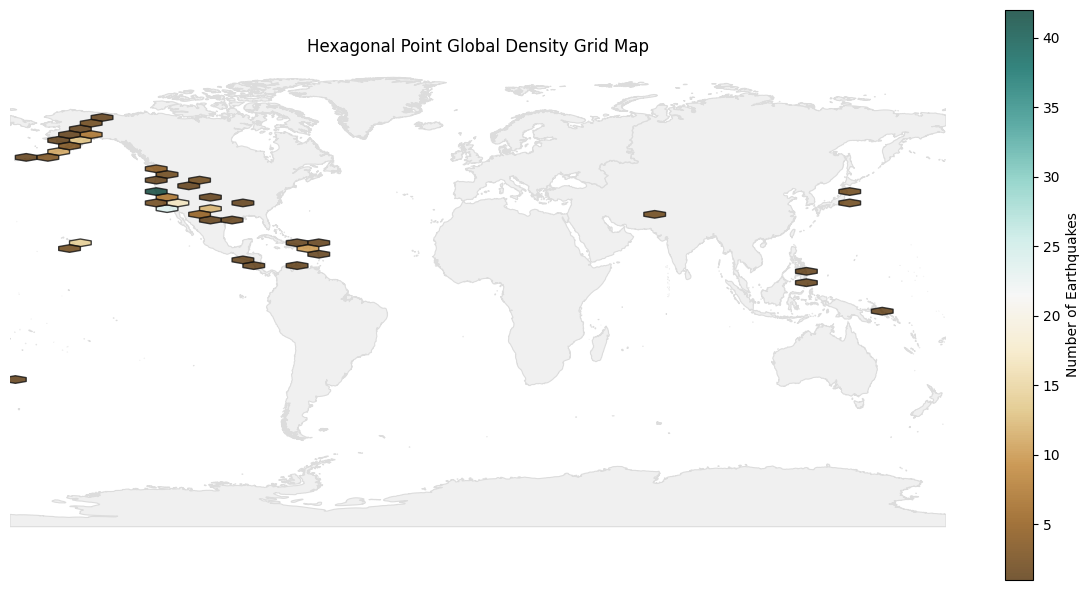

In [215]:
world_url = "https://github.com/opengeos/datasets/releases/download/world/continents.geojson"
world_gdf = gpd.read_file(world_url)

fig, ax = plt.subplots(figsize = (12,6))
ax.set_facecolor('black')

world_gdf.plot(ax=ax, color='#f0f0f0', edgecolor='#dcdcdc', linewidth=0.8)

hb = ax.hexbin (
    gdf.geometry.x,
    gdf.geometry.y,
    gridsize = 40,
    cmap = 'BrBG',
    mincnt = 1,
    alpha = 0.8,
    edgecolors = '#111111',
)

fig.colorbar(hb, ax = ax, label = 'Number of Earthquakes')
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.axis('off')
plt.title("Hexagonal Point Global Density Grid Map")
plt.tight_layout()
plt.show()

In [156]:
# types of earthquakes (crustal, upper mantle, deep mantle)

In [202]:
def earthquake_layer(z_depth):
    if z_depth <= 70:
        return 'Crustal'
    elif z_depth <= 300:
        return 'Upper Mantle'
    else:
        return 'Deep Mantle'

In [203]:
gdf['earthquake_type'] = gdf.geometry.z.apply(earthquake_layer)

In [204]:
print(gdf['earthquake_type'].value_counts())

earthquake_type
Crustal         200
Upper Mantle      9
Name: count, dtype: int64


In [160]:
upper_mantle = gdf[gdf['earthquake_type'] == 'Upper Mantle']

In [206]:
max_depth = upper_mantle.geometry.z.max()

In [207]:
print(f"The deepest earthquake in the past 24 hours was at {max_depth:.2f} km.")

The deepest earthquake in the past 24 hours was at 191.50 km.


In [208]:
plt.figure(figsize = (10,5))

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

In [209]:
plt.rcParams['text.color'] = 'black'

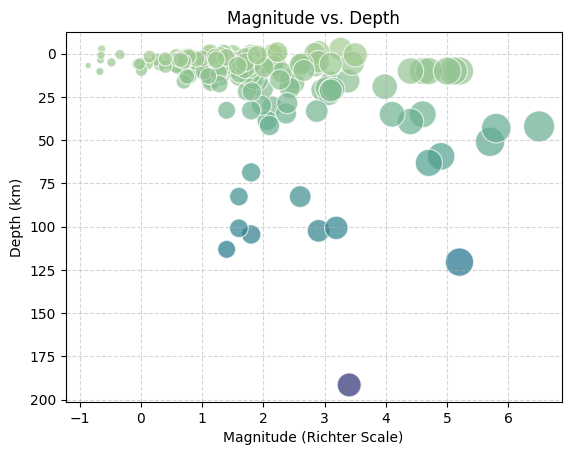

In [210]:
sns.scatterplot (
    x = gdf['mag'],
    y = gdf.geometry.z,
    hue = gdf.geometry.z,
    size = gdf['mag'],
    sizes = (20, 500),
    palette = 'crest',
    alpha = 0.7,
    legend = False
)

plt.gca().invert_yaxis()
plt.title("Magnitude vs. Depth")
plt.xlabel("Magnitude (Richter Scale)")
plt.ylabel("Depth (km)")
plt.grid(True, linestyle= '--', alpha = 0.5)
plt.show()

In [214]:
# detection ability by proximity to stations
# USGS data is not perfect as sensors can detect earthquakes close enough best 
# earthquakes decay fast -- earthquakes far from a station usually have a large min magnitude to be recorded 

In [212]:
gdf['station_proximity'] = pd.qcut(gdf['dmin'], q = 3, labels = ['Near Station', 'Moderate Distance', 'Far From Station'])
min_magnitude = gdf.groupby('station_proximity')['mag'].agg(['min', 'mean', 'count'])
print("Station Proximity and Detection by Distance")
print(min_magnitude)

Station Proximity and Detection by Distance
                    min      mean  count
station_proximity                       
Near Station      -0.67  1.044947     70
Moderate Distance -0.86  1.483043     69
Far From Station  -0.05  2.689857     70
